In [24]:
import torch as th
import torch.nn as nn
import torchvision.transforms as T
import torchvision
import matplotlib.pylab as plt
import numpy as np

### Import Data

In [25]:
import kagglehub

path = kagglehub.dataset_download("asaniczka/pc-parts-images-dataset-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pc-parts-images-dataset-classification' dataset.
Path to dataset files: /kaggle/input/pc-parts-images-dataset-classification


In [26]:
import os
print(os.listdir(path))

path=os.path.join(path, "pc_parts")
print(os.listdir(path))

['pc_parts']
['microphone', 'monitor', 'webcam', 'motherboard', 'hdd', 'gpu', 'cables', 'mouse', 'case', 'keyboard', 'cpu', 'headset', 'speakers', 'ram']


In [27]:
t=T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])
image=torchvision.datasets.ImageFolder(path, transform=t)

### Split Data

In [33]:
train=th.randperm(len(image))[600:]
test=th.randperm(len(image))[:600]

In [34]:
train=th.utils.data.Subset(image, train)
test=th.utils.data.Subset(image, test)

In [35]:
train=th.utils.data.DataLoader( train, batch_size=64, shuffle=True)
test=th.utils.data.DataLoader( test, batch_size=300)

In [36]:
print(f"Train samples: {len(train)}")
print(f"Test samples:  {len(test)}")

Train samples: 42
Test samples:  2


### Show sample data

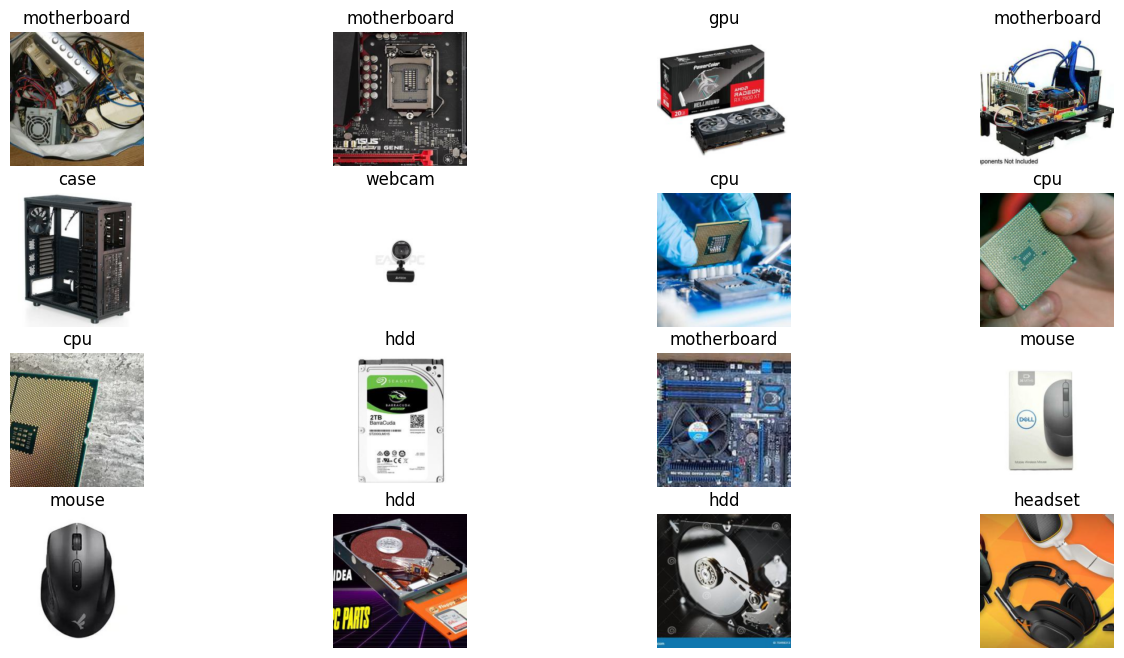

In [37]:
x,y=next(iter(train))
fig,ax=plt.subplots(4,4, figsize=(16,8))
i=1
for row in range(4):
  for col in range(4):
    ax[row,col].imshow(x[i].permute(1,2,0))
    ax[row,col].set_title(image.classes[y[i]])
    ax[row,col].axis("off")
    i += 1


### Build a deep learning model

In [38]:
import torch.nn.functional as F
class model(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(3,16,3,padding=1)
    h1=((224-3+2)/1+1)//2
    self.conv2=nn.Conv2d(16,32,3,padding=1)
    h2=((h1-3+2)/1+1)//2
    self.conv3=nn.Conv2d(32,48,3,padding=1)
    h3=((h2-3+2)/1+1)//2

    self.fc1=nn.Linear(int(48*h3*h3), 128)
    self.fc2=nn.Linear(128,14)
  def forward(self, x):
    x=th.relu(F.max_pool2d(self.conv1(x),2))
    x=th.relu(F.max_pool2d(self.conv2(x),2))
    x=th.relu(F.max_pool2d(self.conv3(x),2))
    x=nn.Flatten()(x)
    x=th.relu(self.fc1(x))
    x=self.fc2(x)
    return x

class CNN(nn.Module):
  def __init__(self, num_classes: int = 14):
    super().__init__()
    self.features = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.Conv2d(32, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2),

      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(2),

      nn.Dropout(0.3),#0.25
      nn.AdaptiveAvgPool2d((7, 7)),

    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(64 * 7 * 7, 256),
      nn.ReLU(inplace=True),
      nn.Dropout(0.5),
      nn.Linear(256, num_classes),
    )
  def forward(self, x):
      x = self.features(x)
      x = self.classifier(x)
      return x

class myCNN(nn.Module):
  def __init__(self, num_classes=14):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 32, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 56 * 56, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, 64),
        nn.ReLU(inplace=True),
        nn.Linear(64, 32),
        nn.ReLU(inplace=True),
        nn.Dropout(0.1),
        nn.Linear(32, num_classes)
    )
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

class myCNNN(nn.Module):
  def __init__(self, num_classes=14):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d((14,14)),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*14*14, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [39]:
net=myCNNN()
print(x.shape)
y_hat=net.forward(x)
loss=nn.CrossEntropyLoss()
print(loss(y_hat,y))
print(y_hat.shape)

torch.Size([64, 3, 224, 224])
tensor(2.6600, grad_fn=<NllLossBackward0>)
torch.Size([64, 14])


### Summary

In [40]:
!pip install torchsummary


In [41]:
from torchsummary import summary
summary(net, (3, 224, 224),device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
              ReLU-5         [-1, 64, 112, 112]               0
         MaxPool2d-6           [-1, 64, 56, 56]               0
 AdaptiveAvgPool2d-7           [-1, 64, 14, 14]               0
           Flatten-8                [-1, 12544]               0
            Linear-9                  [-1, 128]       1,605,760
             ReLU-10                  [-1, 128]               0
          Dropout-11                  [-1, 128]               0
           Linear-12                   [-1, 14]           1,806
Total params: 1,626,958
Trainable params: 1,626,958
Non-trainable params: 0
---------------------------

### Method to train the model

In [42]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def fit(train, test, epoch=25):
  dev=th.device("cuda" if th.cuda.is_available() else "cpu")
  net=model().to(dev)
  optim=th.optim.Adam(net.parameters(), lr=1e-3)
  loss=nn.CrossEntropyLoss()
  scheduler = ReduceLROnPlateau(optim, mode='min', factor=0.1, patience=4)

  train_acu=np.zeros(epoch)
  train_loss=np.zeros(epoch)
  test_acu=np.zeros(epoch)
  test_loss=np.zeros(epoch)

  for i in range(epoch):
    a, b = [], []
    net.train()
    for x,y in train:
      x, y = x.to(dev), y.to(dev)
      y_hat = net.forward(x)
      l = loss(y_hat,y)

      optim.zero_grad()
      l.backward()
      optim.step()

      l=l.cpu()
      y_hat=y_hat.cpu()
      y=y.cpu()

      a.append(l.item())
      k=100*th.mean((th.argmax(y_hat,axis=1)==y).float()).item()
      b.append(k)

    train_acu[i]=np.mean(b)
    train_loss[i]=np.mean(a)
    net.eval()
    a = []
    b = []
    with th.no_grad():
      for x, y in test:
        x, y = x.to(dev), y.to(dev)
        y_hat = net(x)
        l = loss(y_hat, y)
        a.append(l.item())
        b.append(100 * th.mean((th.argmax(y_hat, dim=1) == y).float()).item())

    test_loss[i] = np.mean(a)
    test_acu[i] = np.mean(b)

    scheduler.step(test_loss[i])
    current_lr = optim.param_groups[0]['lr']
    print(f'current_lr:{current_lr}')

    print(f"Epoch {i}: Train Loss: {train_loss[i]}, Train Accuracy: {train_acu[i]}  Test Loss: {test_loss[i]}, Test Accuracy: {test_acu[i]}")

  return train_acu, train_loss, test_acu, test_loss,net

### Train The Model

In [43]:
train_acu, train_loss, test_acu, test_loss, net = fit(train, test, 20)

current_lr:0.001
Epoch 0: Train Loss: 2.6390293495995656, Train Accuracy: 9.399350643867539  Test Loss: 2.592129945755005, Test Accuracy: 12.666667252779007
current_lr:0.001
Epoch 1: Train Loss: 2.5476157665252686, Train Accuracy: 13.590367954401742  Test Loss: 2.4758646488189697, Test Accuracy: 17.499999701976776
current_lr:0.001
Epoch 2: Train Loss: 2.427062295732044, Train Accuracy: 19.411525981766836  Test Loss: 2.334406018257141, Test Accuracy: 22.66666740179062
current_lr:0.001
Epoch 3: Train Loss: 2.268674998056321, Train Accuracy: 26.244588763940904  Test Loss: 2.13748836517334, Test Accuracy: 31.333333253860474
current_lr:0.001
Epoch 4: Train Loss: 2.0837949372473217, Train Accuracy: 32.12121214185442  Test Loss: 1.9598137736320496, Test Accuracy: 35.16666740179062
current_lr:0.001
Epoch 5: Train Loss: 1.865379688285646, Train Accuracy: 38.60119049038206  Test Loss: 1.7099525332450867, Test Accuracy: 45.83333432674408
current_lr:0.001
Epoch 6: Train Loss: 1.500619161696661, Tr

### Show the model results

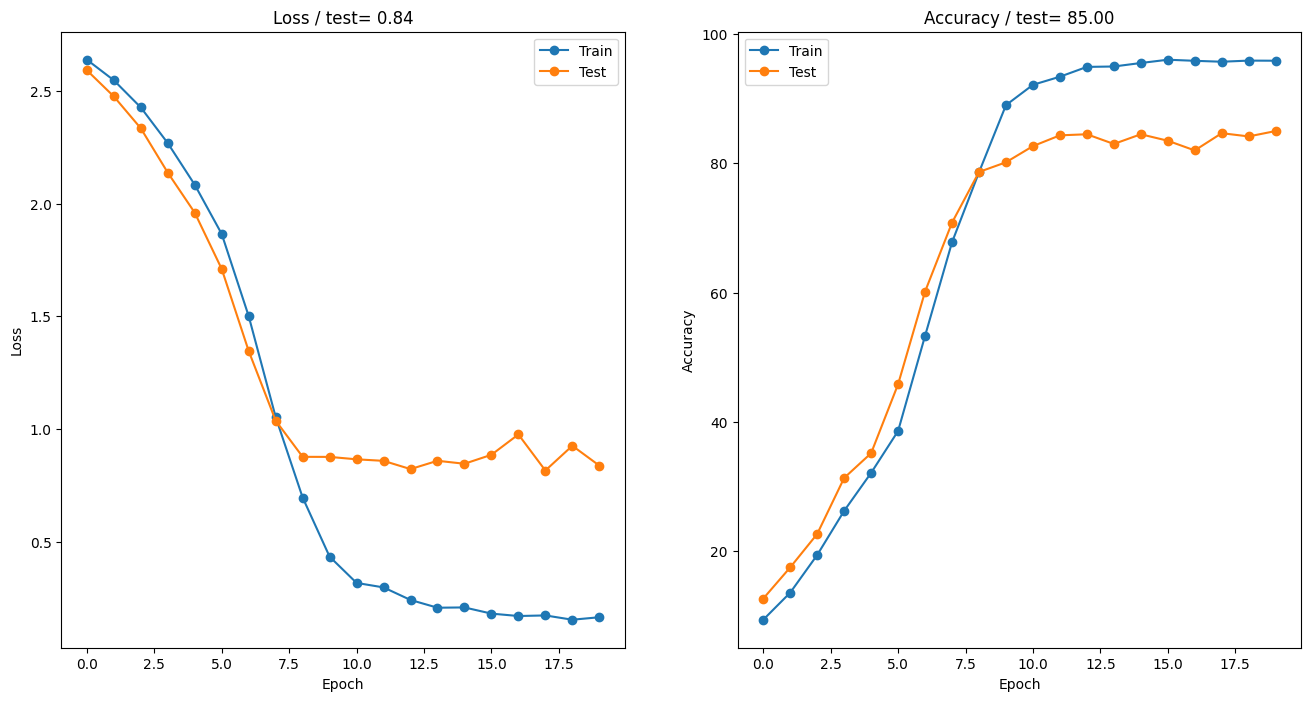

In [44]:
fig,ax=plt.subplots(1,2, figsize=(16,8))
ax[0].plot(train_loss,'o-')
ax[0].plot(test_loss,'o-')
ax[0].set_title(f"Loss / test= {test_loss[-1]:.2f}")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel('Loss')
ax[0].legend(["Train","Test"])

ax[1].plot(train_acu,'o-')
ax[1].plot(test_acu,'o-')
ax[1].set_title(f"Accuracy / test= {test_acu[-1]:.2f}")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend(["Train","Test"])


### Evaluation metrics

In [45]:
next(iter(test))
x,y=next(iter(test))

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")
x = x.to(device)

y_hat=net.forward(x)
y_hat=y_hat.cpu()
print(100*th.mean((th.argmax(y_hat,axis=1)==y).float()))


tensor(88.6667)


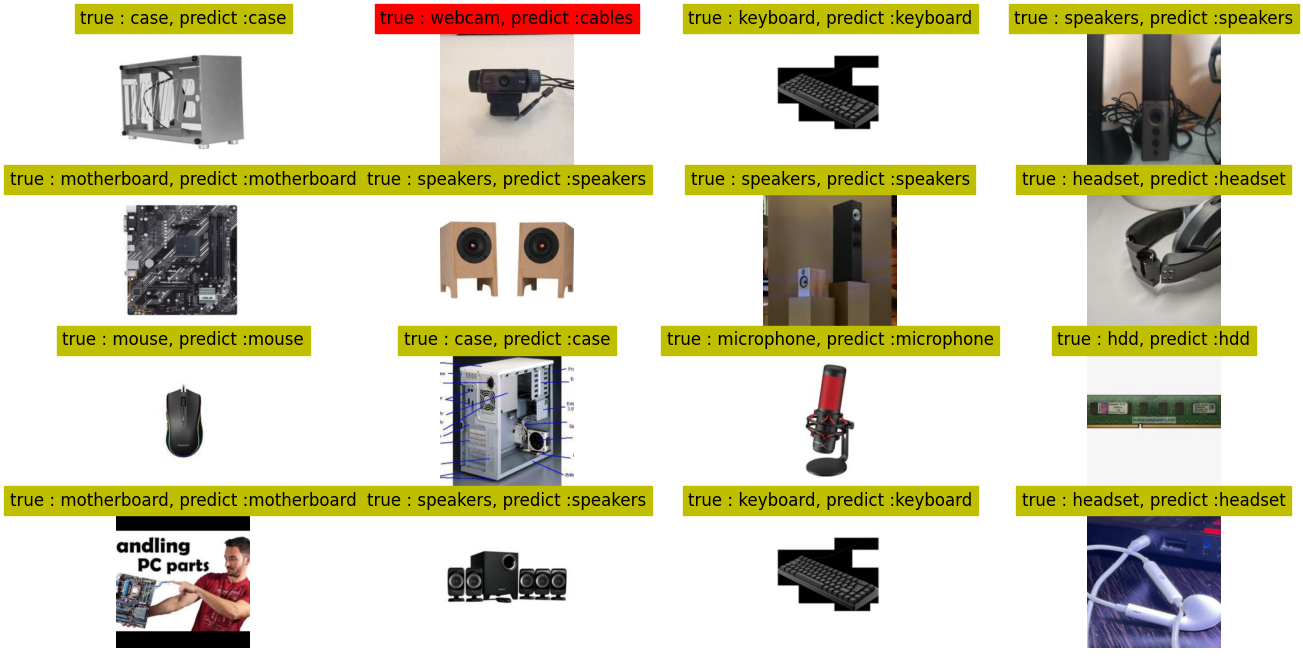

In [46]:
x=x.cpu()
fig,ax=plt.subplots(4,4, figsize=(16,8))
y_hat1=th.argmax(y_hat,axis=1)
for row in range(4):
  for col in range(4):
    co=np.random.choice(x.shape[0],1)[0]
    ax[row,col].imshow(th.permute(x[co],(1,2,0)))
    ax[row,col].axis('off')

    d=f'true : {image.classes[y[co]]}, predict :{image.classes[y_hat1[co]]}'

    if y[co]==y_hat1[co]: ax[row,col].set_title(d,color='k',backgroundcolor='y')
    else: ax[row,col].set_title(d,color='k',backgroundcolor='r')

([<matplotlib.axis.XTick at 0x7d6da724deb0>,
 [Text(0, 0, 'cables'),
  Text(1, 0, 'case'),
  Text(2, 0, 'cpu'),
  Text(3, 0, 'gpu'),
  Text(4, 0, 'hdd'),
  Text(5, 0, 'headset'),
  Text(6, 0, 'keyboard'),
  Text(7, 0, 'microphone'),
  Text(8, 0, 'monitor'),
  Text(9, 0, 'motherboard'),
  Text(10, 0, 'mouse'),
  Text(11, 0, 'ram'),
  Text(12, 0, 'speakers'),
  Text(13, 0, 'webcam')])

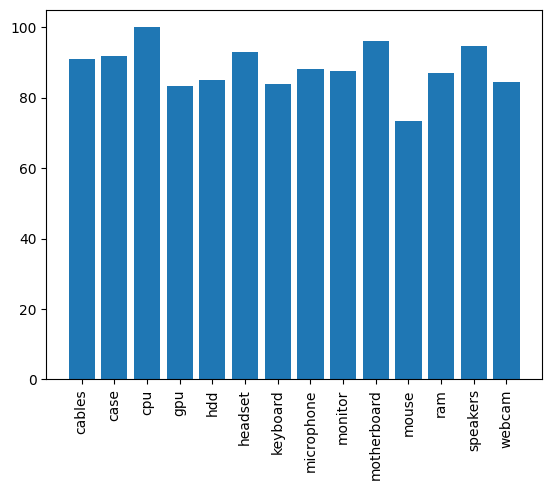

In [47]:
import  sklearn.metrics as m

k=(th.argmax(y_hat,axis=1)==y).float()
acu_group=np.zeros(14)

for i in range(14): acu_group[i]=100*th.mean(k[y==i])
plt.bar(np.arange(14),acu_group)
plt.xticks(np.arange(14),image.classes,rotation=90)

In [48]:
print(m.classification_report(y.detach(),th.argmax(y_hat,axis=1).detach()))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        22
           1       0.92      0.92      0.92        25
           2       0.67      1.00      0.80        12
           3       0.83      0.83      0.83        18
           4       0.96      0.85      0.90        27
           5       0.96      0.93      0.95        29
           6       0.84      0.84      0.84        31
           7       1.00      0.88      0.94        17
           8       0.95      0.88      0.91        24
           9       0.92      0.96      0.94        25
          10       0.92      0.73      0.81        15
          11       0.95      0.87      0.91        23
          12       0.82      0.95      0.88        19
          13       0.92      0.85      0.88        13

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.88       300
weighted avg       0.90      0.89      0.89       300



### Confusion Matrix


([<matplotlib.axis.YTick at 0x7d6da72de3f0>,
 [Text(0, 0, 'cables'),
  Text(0, 1, 'case'),
  Text(0, 2, 'cpu'),
  Text(0, 3, 'gpu'),
  Text(0, 4, 'hdd'),
  Text(0, 5, 'headset'),
  Text(0, 6, 'keyboard'),
  Text(0, 7, 'microphone'),
  Text(0, 8, 'monitor'),
  Text(0, 9, 'motherboard'),
  Text(0, 10, 'mouse'),
  Text(0, 11, 'ram'),
  Text(0, 12, 'speakers'),
  Text(0, 13, 'webcam')])

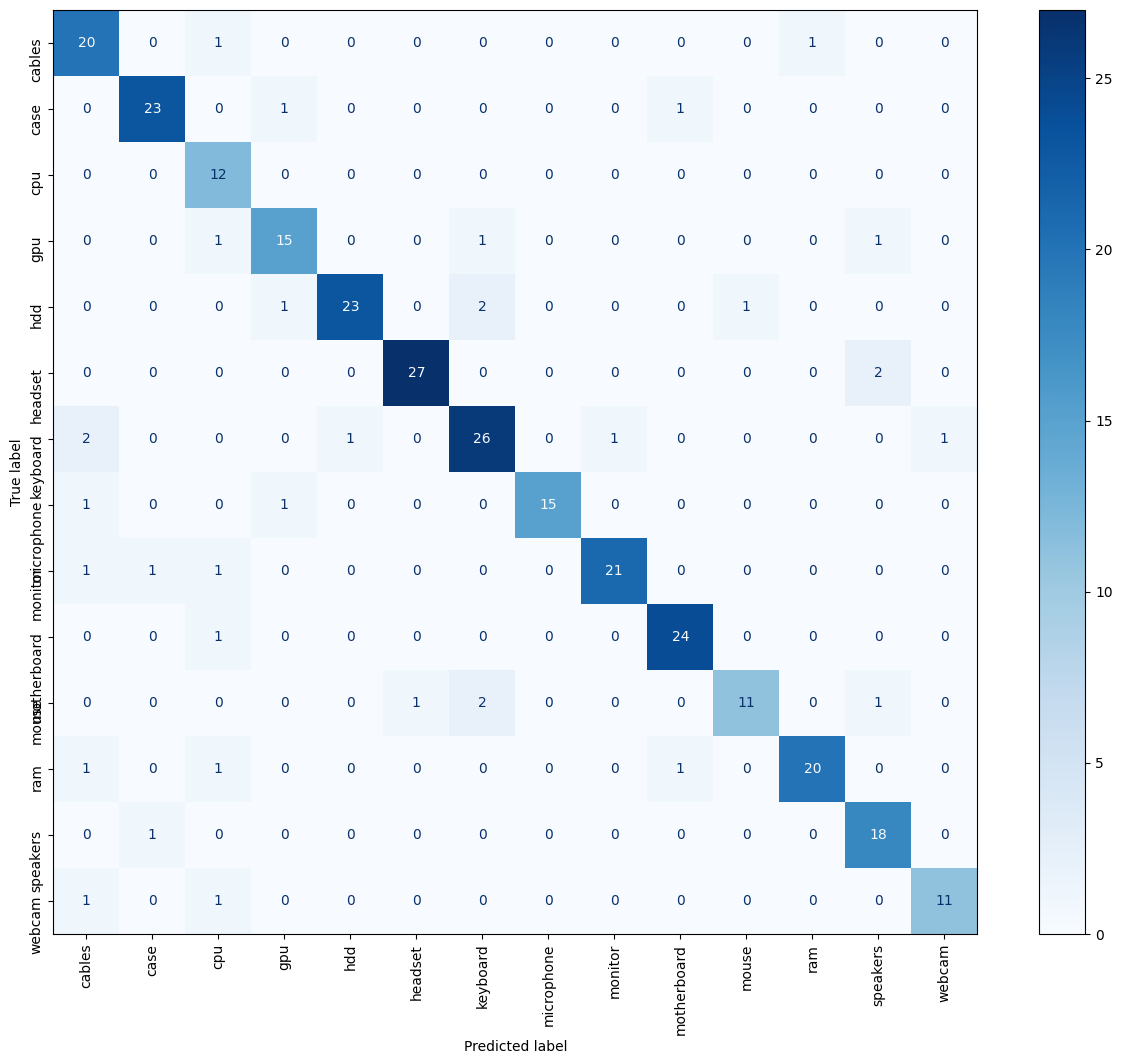

In [49]:
fig,ax=plt.subplots(figsize=(16,12))
a=m.ConfusionMatrixDisplay(m.confusion_matrix(y.detach(),th.argmax(y_hat,axis=1).detach()))
a.plot(cmap='Blues',ax=ax)
plt.xticks(np.arange(14),image.classes,rotation=90)
plt.yticks(np.arange(14),image.classes,rotation=90)